# LeNet-5 em PyTorch

Este notebook apresenta a implementação da arquitetura LeNet-5, incluindo visualizações, treinamento, avaliação e salvamento do modelo.

## 1) Definição da Arquitetura LeNet-5

Nesta seção, importamos as bibliotecas e declaramos a classe do modelo.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # Layer 1: Convolutional layer with 6 filters of size 5x5, padding 2
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2)
        # Layer 2: Max Pooling layer with 2x2 kernel and stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Layer 3: Convolutional layer with 16 filters of size 5x5
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        # Layer 4: Max Pooling layer with 2x2 kernel and stride 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Layer 5: Convolutional layer with 120 filters of size 5x5
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1)

        # Layer 6: Fully connected layer
        self.fc1 = nn.Linear(in_features=120, out_features=84)

        # Layer 7: Output layer
        self.fc2 = nn.Linear(in_features=84, out_features=num_classes)

    def forward(self, x):
        # Pass through first conv + pool
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        # Pass through second conv + pool
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        # Pass through third conv
        x = F.relu(self.conv3(x))

        # Flatten and pass through fully connected layers
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))

        # Output layer (no activation here, usually handled by CrossEntropyLoss)
        x = self.fc2(x)
        return x

## 2) Instanciação do Modelo

Criamos uma instância da LeNet-5 para usar nas próximas etapas.

In [2]:
# Cria uma instância do modelo
model = LeNet5(num_classes=10)
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


## 3) Visualização dos Filtros Iniciais

Antes do treinamento, observamos os filtros convolucionais para entender como os pesos começam.

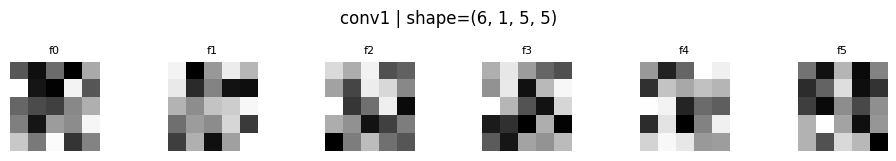

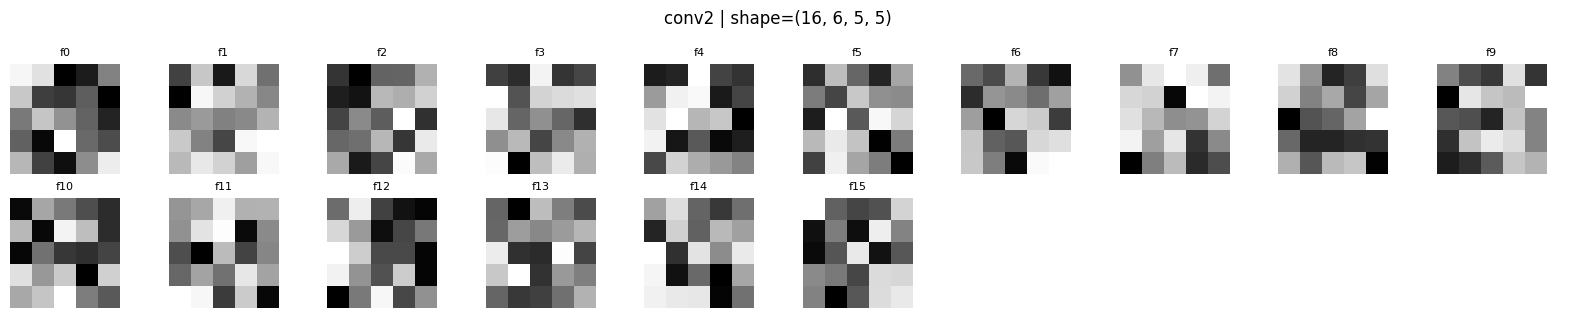

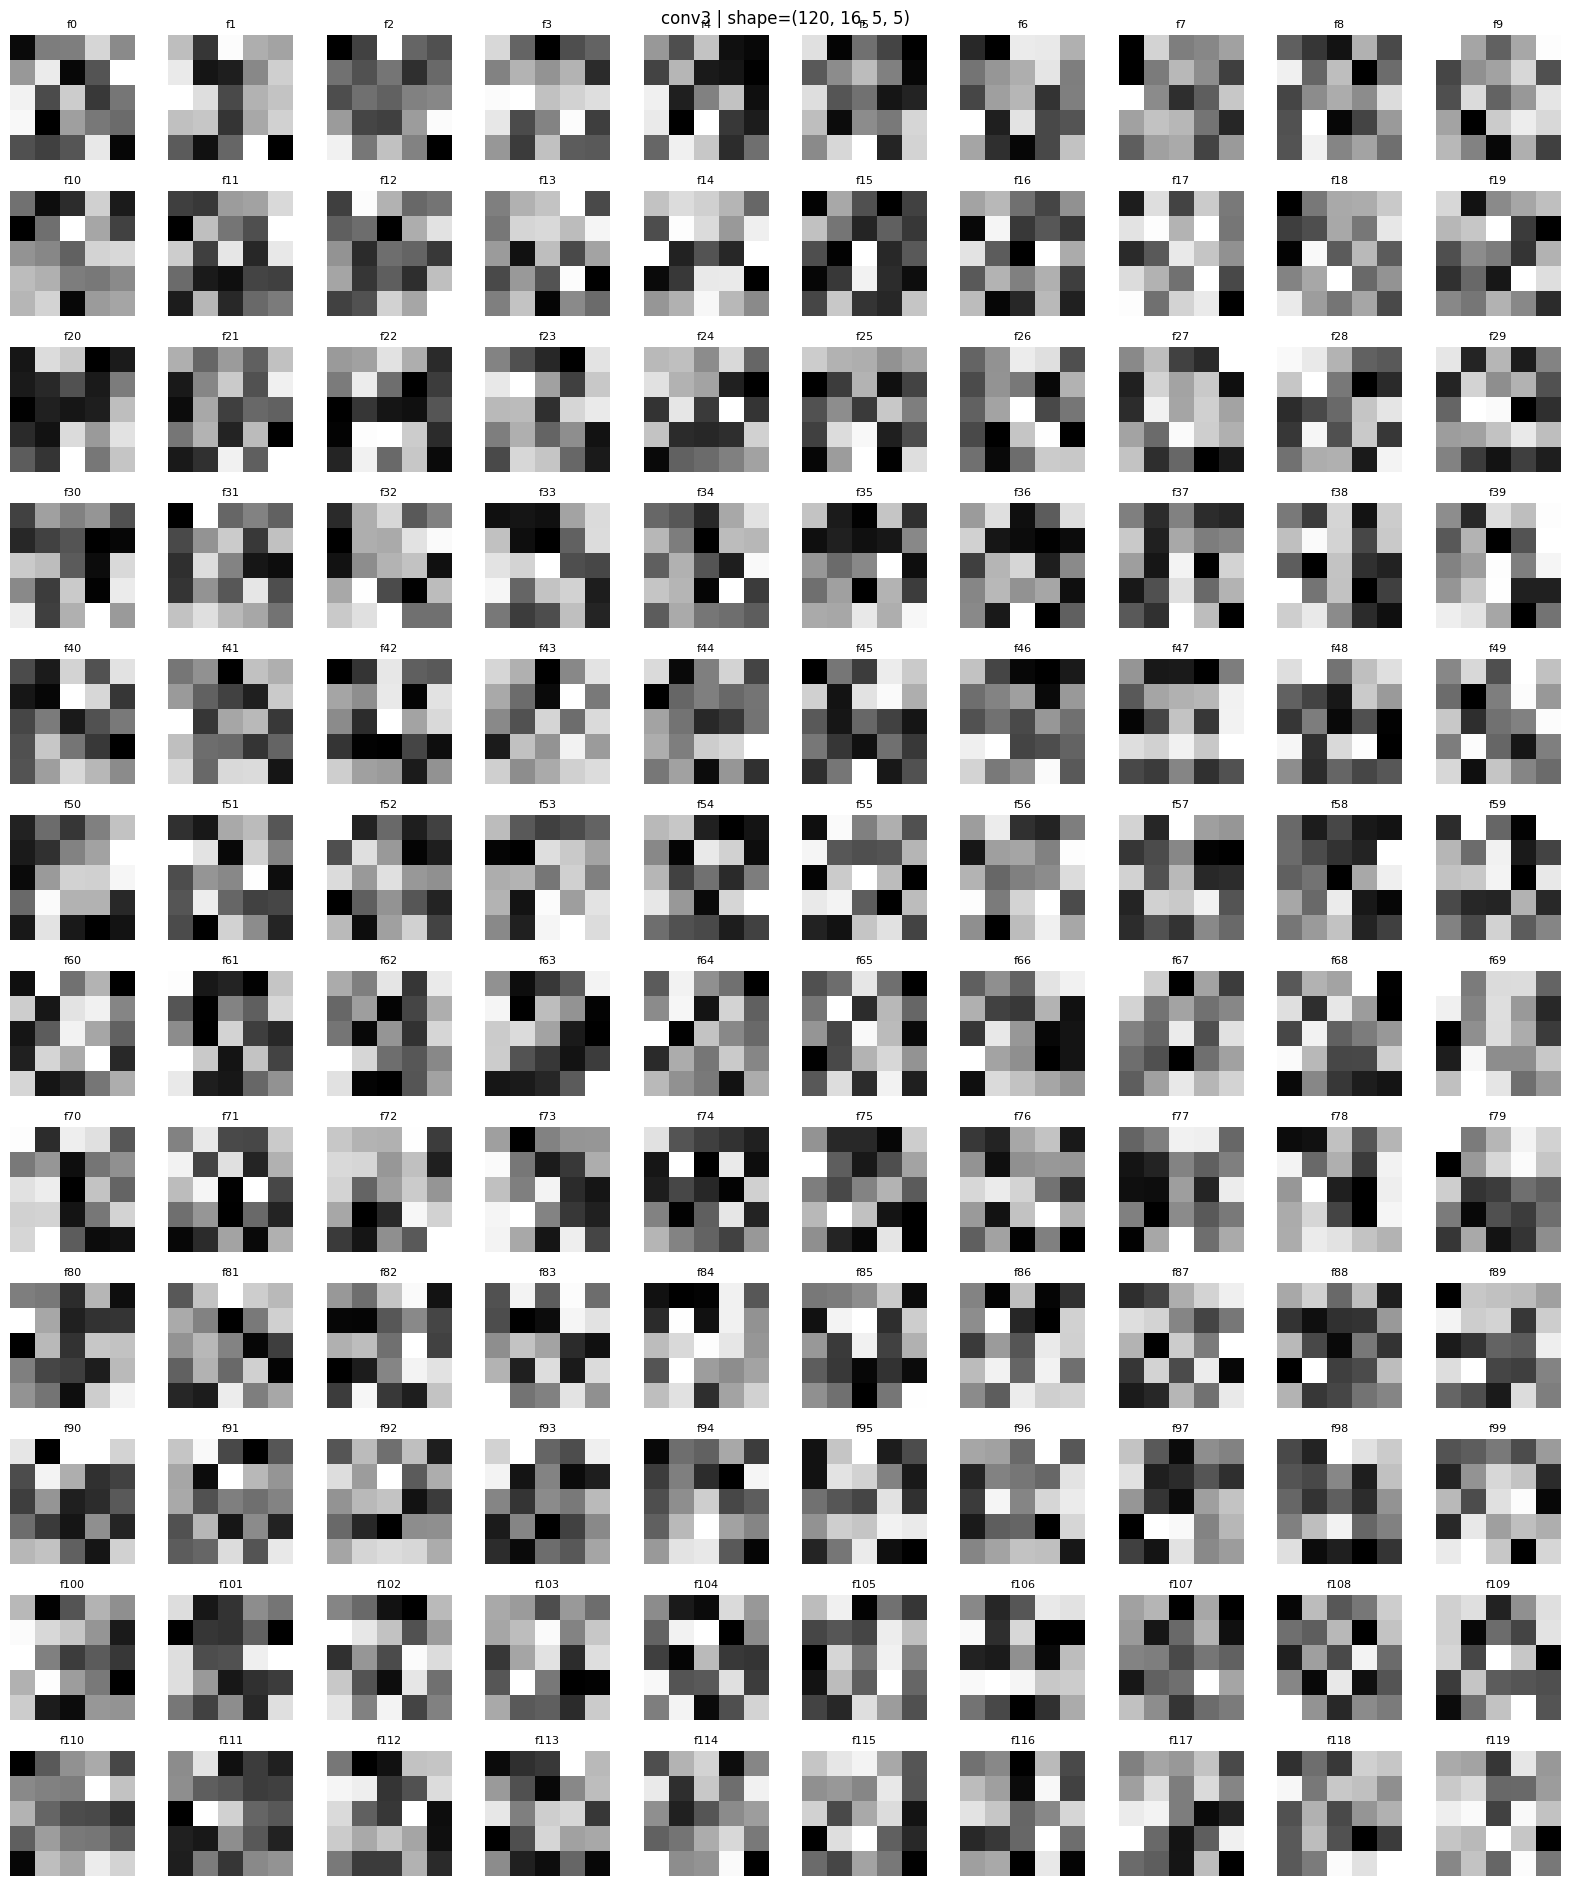

In [3]:
# Visualização dos filtros convolucionais iniciais (antes do treinamento)
import math
import matplotlib.pyplot as plt

with torch.no_grad():
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            weights = module.weight.detach().cpu()

            # Mostra todos os filtros de saída usando o primeiro canal de entrada
            filters = weights[:, 0, :, :]
            n_filters = filters.shape[0]
            cols = min(10, n_filters)
            rows = math.ceil(n_filters / cols)

            fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
            axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

            for i in range(len(axes)):
                ax = axes[i]
                ax.axis("off")
                if i < n_filters:
                    ax.imshow(filters[i], cmap="gray")
                    ax.set_title(f"f{i}", fontsize=8)

            fig.suptitle(f"{name} | shape={tuple(weights.shape)}", fontsize=12)
            plt.tight_layout()
            plt.show()

## 4) Carregamento do MNIST e Visualização de Amostras

Carregamos o dataset MNIST local (já baixado em `./data`) e exibimos algumas imagens para inspeção visual.

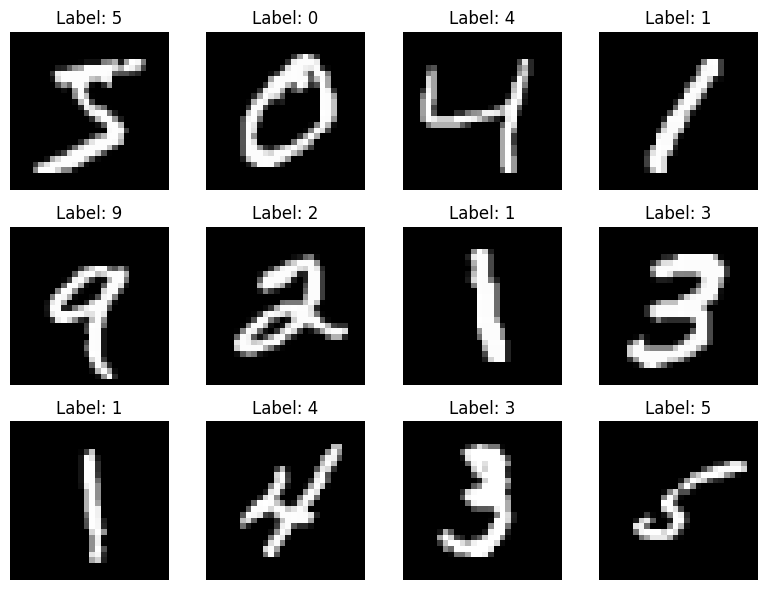

In [4]:
from torchvision import datasets, transforms

# Usa o MNIST já disponível localmente em ./data
transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=False, transform=transform)

# Exibe alguns exemplos do dataset
num_examples = 12
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
axes = axes.flatten()

for i in range(num_examples):
    image, label = mnist_train[i]
    axes[i].imshow(image.squeeze(0), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 5) Treinamento da Rede Neural

Definimos os hiperparâmetros, criamos o `DataLoader` e executamos o loop de treinamento por época.

In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim

# Hiperparâmetros de treinamento
learning_rate = 0.001
batch_size = 64
num_epochs = 5

# Usa os arquivos do MNIST já baixados localmente
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch [{epoch + 1}/{num_epochs}] - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")

Epoch [1/5] - loss: 0.2807 - acc: 0.9109
Epoch [2/5] - loss: 0.0752 - acc: 0.9771
Epoch [3/5] - loss: 0.0543 - acc: 0.9831
Epoch [4/5] - loss: 0.0433 - acc: 0.9864
Epoch [5/5] - loss: 0.0357 - acc: 0.9886


## 6) Avaliação no Conjunto de Teste

Aqui medimos a performance do modelo com dados que ele não viu durante o treinamento.

In [6]:
# Avaliação no conjunto de teste
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

avg_test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Test Loss: 0.0572
Test Accuracy: 0.9825 (98.25%)


## 7) Análise de Erros de Classificação

Nesta etapa, visualizamos exemplos que o modelo classificou incorretamente para entender seus principais erros.

In [7]:
# Visualiza exemplos que a rede neural classificou incorretamente
# (mostra os primeiros 16 erros encontrados)
num_errors_to_show = 16
misclassified_images = []
misclassified_true = []
misclassified_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        wrong_mask = preds != labels
        if wrong_mask.any():
            wrong_images = images[wrong_mask].cpu()
            wrong_labels = labels[wrong_mask].cpu()
            wrong_preds = preds[wrong_mask].cpu()

            for img, true_label, pred_label in zip(wrong_images, wrong_labels, wrong_preds):
                misclassified_images.append(img)
                misclassified_true.append(true_label.item())
                misclassified_pred.append(pred_label.item())

                if len(misclassified_images) >= num_errors_to_show:
                    break

        if len(misclassified_images) >= num_errors_to_show:
            break

n = len(misclassified_images)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i in range(len(axes)):
    ax = axes[i]
    ax.axis("off")
    if i < n:
        ax.imshow(misclassified_images[i].squeeze(0), cmap="gray")
        ax.set_title(f"Real: {misclassified_true[i]} | Pred: {misclassified_pred[i]}")

plt.tight_layout()
plt.show()

Modelo salvo em: checkpoints/lenet5_mnist.pth


## 8) Saída da Primeira Camada Convolucional

Nesta seção, aplicamos a primeira camada (`conv1`) em uma imagem de teste e visualizamos os mapas de ativação gerados.

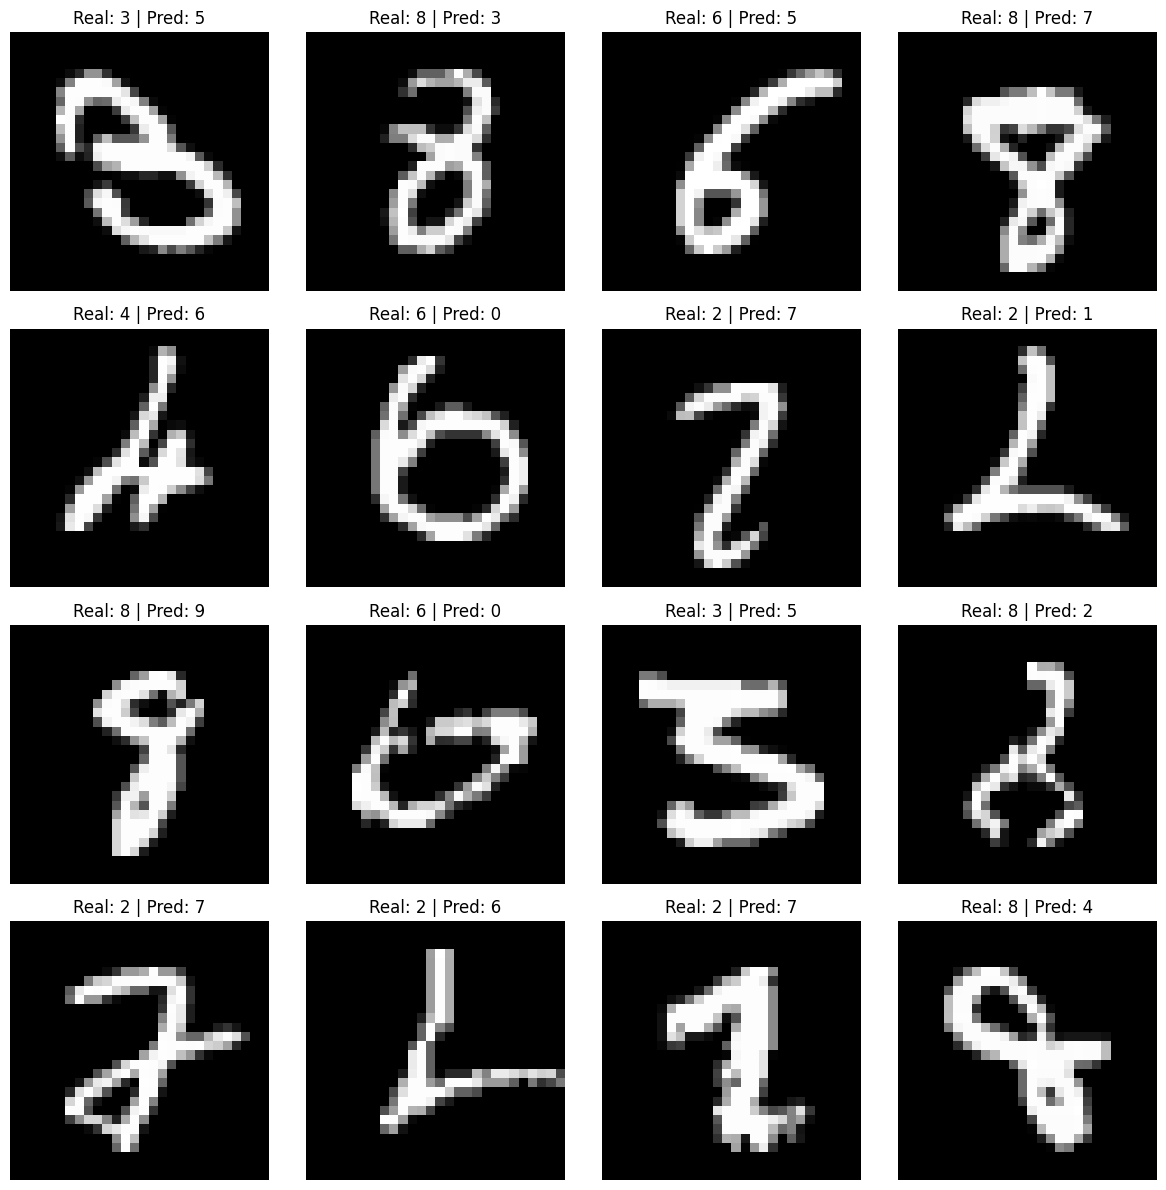

In [8]:
# Visualiza a saída da primeira camada convolucional (conv1)
# Usa uma imagem do conjunto de teste e mostra os mapas de ativação.

# Seleciona o modelo disponível (carregado do checkpoint ou treinado na sessão)
model_to_use = loaded_model if "loaded_model" in globals() else model
model_to_use.eval()

# Seleciona uma imagem de exemplo do conjunto de teste
sample_idx = 0
sample_image, sample_label = test_dataset[sample_idx]

with torch.no_grad():
    x = sample_image.unsqueeze(0).to(device)  # [1, 1, 28, 28]
    conv1_output = model_to_use.conv1(x)
    conv1_activation = F.relu(conv1_output).cpu().squeeze(0)  # [6, H, W]

# Mostra imagem original + mapas de ativação da conv1
num_feature_maps = conv1_activation.shape[0]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

# Imagem original
axes[0].imshow(sample_image.squeeze(0), cmap="gray")
axes[0].set_title(f"Entrada (rótulo: {sample_label})")
axes[0].axis("off")

# Primeiros mapas de ativação da conv1
for i in range(num_feature_maps):
    axes[i + 1].imshow(conv1_activation[i], cmap="viridis")
    axes[i + 1].set_title(f"conv1 mapa {i}")
    axes[i + 1].axis("off")

# Se sobrar subplot, desliga
for j in range(num_feature_maps + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Saída da primeira camada convolucional (após ReLU)", fontsize=12)
plt.tight_layout()
plt.show()

## 9) Salvando o Modelo

Nesta etapa, salvamos os pesos treinados e os principais hiperparâmetros para reutilização futura.

In [ ]:
# Salvar o modelo treinado
import os

os.makedirs("checkpoints", exist_ok=True)
save_path = "checkpoints/lenet5_mnist.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "num_epochs": num_epochs,
    },
    save_path,
)

print(f"Modelo salvo em: {save_path}")

## 10) Carregando o Modelo Salvo

Nesta seção, restauramos a LeNet-5 a partir do checkpoint salvo em disco para continuar testes ou inferência.

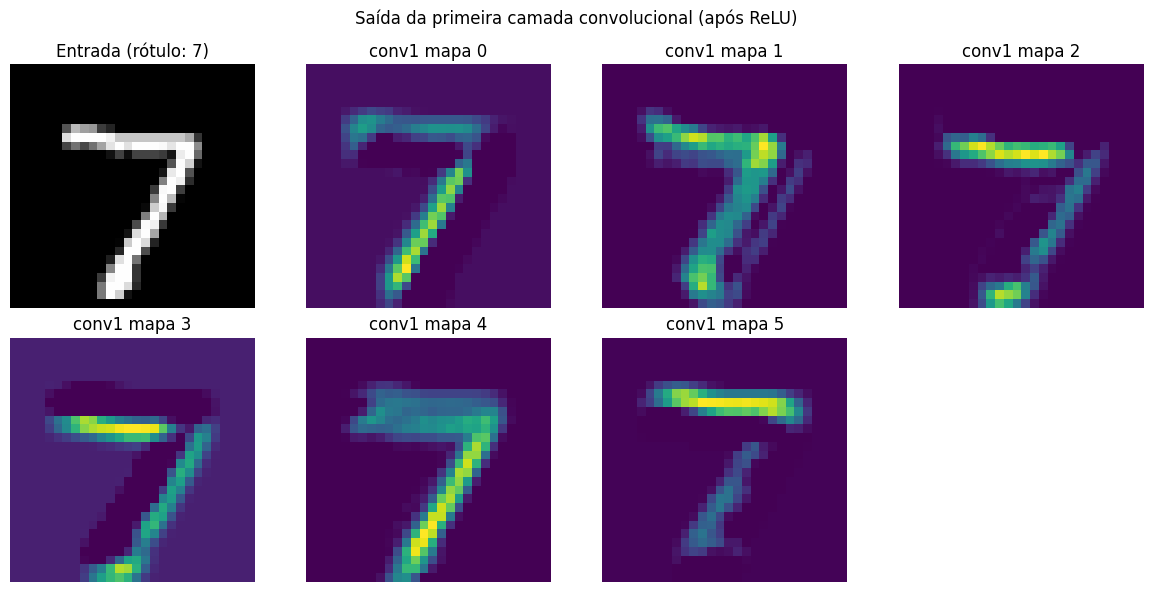

In [9]:
# Carregar o checkpoint salvo da LeNet-5
import os

checkpoint_path = "checkpoints/lenet5_mnist.pth"

# Verifica se o arquivo existe antes de tentar carregar
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint não encontrado em: {checkpoint_path}")

# Carrega o checkpoint no mesmo device (CPU/GPU)
loaded_checkpoint = torch.load(checkpoint_path, map_location=device)

# Recria o modelo e restaura os pesos
loaded_model = LeNet5(num_classes=10).to(device)
loaded_model.load_state_dict(loaded_checkpoint["model_state_dict"])
loaded_model.eval()  # modo de inferência

print(f"Modelo carregado com sucesso de: {checkpoint_path}")
print(
    f"Hyperparameters salvos -> lr={loaded_checkpoint['learning_rate']}, "
    f"batch_size={loaded_checkpoint['batch_size']}, "
    f"num_epochs={loaded_checkpoint['num_epochs']}"
)